# Inférence statistique

> Modèles retenus : CatBoost, XGBoost, LightGBM (cible `log1p`) + Stacking OOF  
> Optimisation sur **MAPE** (au lieu de MAE) + feature engineering ciblé sur les petites valeurs.

## Imports & configuration

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Manipulation de données
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import json


# Modèles
from sklearn.linear_model import LinearRegression

# Évaluation et validation
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)

from sklearn.inspection import permutation_importance

# Modèles de Gradient Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Optimisation d'hyperparamètres
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


import shap
from sklearn.base import BaseEstimator, RegressorMixin

from sklearn.impute import SimpleImputer
import lime
import lime.lime_tabular

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 

RANDOM_STATE = 1308

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### A.2 : Chargement des données

Split **temporel** : train 2020-2022 / val 2023 / test 2024. On entraîne toujours sur le passé et on évalue sur le futur.

In [3]:
# Chargement des données

df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")
df_en_cours = pd.read_csv("../data_finale/featuring/en_cours_featured.csv")

# On supprime les lignes avec des valeurs manquantes pour notre variable cible

colonne_cible  = "market_value_in_eur"

df_train = df_train.dropna(subset=[colonne_cible])
df_val   = df_val.dropna(subset=[colonne_cible])
df_test  = df_test.dropna(subset=[colonne_cible])
df_en_cours = df_en_cours.dropna(subset=[colonne_cible])

In [4]:
# Colonnes à supprimer pour l'entraînement

colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

cols_a_supprimer = [colonne_cible, colonne_joueur, colonne_team, colonne_nation, "position"]

X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val = df_val.drop(columns=cols_a_supprimer)
y_val = df_val[colonne_cible]

X_test = df_test.drop(columns=cols_a_supprimer)
y_test = df_test[colonne_cible]

X_en_cours = df_en_cours.drop(columns=cols_a_supprimer)
y_en_cours = df_en_cours[colonne_cible]

In [5]:
# Préparation pour certains modèles : sélection dynamique des colonnes sans aucun NaN
colonnes_sans_nan = X_train.columns[X_train.isna().sum() == 0].tolist()

print(f"Filtrage pour les modèles linéaires/SVR :")
print(f"{len(colonnes_sans_nan)} colonnes conservées sur {X_train.shape[1]}.")

X_train_sans_nan = X_train[colonnes_sans_nan]
X_val_sans_nan   = X_val[colonnes_sans_nan]
X_test_sans_nan  = X_test[colonnes_sans_nan]
X_en_cours_sans_nan = X_en_cours[colonnes_sans_nan]

Filtrage pour les modèles linéaires/SVR :
145 colonnes conservées sur 154.


### A.4 : Préparation des jeux de données X / y

In [6]:
cols_a_supprimer = [
    colonne_cible, colonne_joueur, colonne_team, colonne_nation,
    "position"
]

# On supprime uniquement les colonnes qui existent réellement

# On supprime (ou non) les colonnes normalisées
cols_a_supprimer = [c for c in cols_a_supprimer if c in df_train.columns]
colonnes_nor = [c for c in df_train.columns if c.endswith("_nor")]

df_train = df_train.drop(columns=colonnes_nor, errors="ignore")
df_val   = df_val.drop(columns=colonnes_nor, errors="ignore")
df_test  = df_test.drop(columns=colonnes_nor, errors="ignore")
df_en_cours = df_en_cours.drop(columns=colonnes_nor, errors="ignore")

# Construction des datasets d'entraînement, validation et test
X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val   = df_val.drop(columns=cols_a_supprimer)
y_val   = df_val[colonne_cible]

X_test  = df_test.drop(columns=cols_a_supprimer)
y_test  = df_test[colonne_cible]

X_en_cours  = df_en_cours.drop(columns=cols_a_supprimer)
y_en_cours  = df_en_cours[colonne_cible]

# Cibles log
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)
y_en_cours_log  = np.log1p(y_en_cours)

# Poids d'entraînement : sur-pondère les petites valeurs pour améliorer le MAPE
sample_weights_train = 1 / np.log1p(y_train)
sample_weights_train = sample_weights_train / sample_weights_train.mean()

print(f"X_train : {X_train.shape} | X_val : {X_val.shape} | X_test : {X_test.shape}")

X_train : (7404, 146) | X_val : (2431, 146) | X_test : (1751, 146)


### B2 : Comparaison des algorithmes (cible log)

**Ce qu'on teste :** quel algorithme, tuné avec Optuna, donne les meilleures performances ?

**Modèles comparés :** Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, SVR et ElasticNet.

**Objectif Optuna :** RMSE log. On entraîne sur `log1p(y)` et on retransforme avec `expm1` pour les métriques.

**Ce qui varie ici :** l'algorithme.  
**Ce qui reste fixe :** pipeline Bloc A, objectif RMSE log, `N_TRIALS = 75`, `sample_weight = 1/log1p(y)`.


#### B2.7 — Construction des modèles finaux

In [7]:
with open("../modelisation/meilleurs_hyperparametres.json", "r") as f:
    params = json.load(f)

xgb_final = XGBRegressor(
    **params["XGBoost"],
    tree_method="hist", enable_categorical=True,
    objective="reg:squarederror",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
lgbm_final = LGBMRegressor(
    **params["LightGBM"],
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
cat_final = CatBoostRegressor(
    **params["CatBoost"],
    bootstrap_type="Bernoulli",
    random_state=RANDOM_STATE, early_stopping_rounds=50, verbose=0
)

modeles_finaux = {
    "XGBoost (log)":   xgb_final,
    "LightGBM (log)":  lgbm_final,
    "CatBoost (log)":  cat_final,
}


def evaluer_log(nom, modele, X_tr, y_tr_log, X_ev, y_ev, w=None):
    fit_kwargs = {"sample_weight": w} if w is not None else {}
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_tr, y_tr_log, eval_set=(X_ev, np.log1p(y_ev)), verbose=False, **fit_kwargs)
    else:
        modele.fit(X_tr, y_tr_log, **fit_kwargs)
    preds = np.expm1(modele.predict(X_ev))
    mae   = mean_absolute_error(y_ev, preds)
    rmse  = np.sqrt(mean_squared_error(y_ev, preds))
    mape  = mean_absolute_percentage_error(y_ev, preds)
    r2    = r2_score(y_ev, preds)
    n, p  = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    print(f"  {nom:12s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f} | R²adj : {r2_adj:.4f}")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

print("Évaluation validation")
resultats_val = {}
for nom, modele in modeles_finaux.items():
    resultats_val[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_val, y_val, w=sample_weights_train)

df_val_res = pd.DataFrame(resultats_val).T.sort_values("MAPE")
print("\nClassement validation (MAPE croissant) :")
print(df_val_res)

Évaluation validation
  XGBoost (log) | MAPE : 41.80% | MAE :    3,022,519 € | R² : 0.8957 | R²adj : 0.8890
  LightGBM (log) | MAPE : 42.60% | MAE :    3,101,819 € | R² : 0.8877 | R²adj : 0.8805
  CatBoost (log) | MAPE : 43.14% | MAE :    3,203,065 € | R² : 0.8792 | R²adj : 0.8715

Classement validation (MAPE croissant) :
                         MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost (log)   3.022519e+06  5.813211e+06  0.417998  0.895664   0.888994
LightGBM (log)  3.101819e+06  6.032272e+06  0.426016  0.887652   0.880471
CatBoost (log)  3.203065e+06  6.254052e+06  0.431383  0.879239   0.871520


In [8]:
print("Évaluation test")
resultats_test = {}
for nom, modele in modeles_finaux.items():
    resultats_test[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_test, y_test, w=sample_weights_train)

df_test_res = pd.DataFrame(resultats_test).T.sort_values("MAPE")
print("\nClassement test (MAPE croissant) :")
print(df_test_res)

Évaluation test
  XGBoost (log) | MAPE : 39.67% | MAE :    3,222,725 € | R² : 0.8838 | R²adj : 0.8732
  LightGBM (log) | MAPE : 40.57% | MAE :    3,374,719 € | R² : 0.8778 | R²adj : 0.8666
  CatBoost (log) | MAPE : 40.90% | MAE :    3,495,888 € | R² : 0.8685 | R²adj : 0.8566

Classement test (MAPE croissant) :
                         MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost (log)   3.222725e+06  6.227329e+06  0.396725  0.883819   0.873244
LightGBM (log)  3.374719e+06  6.387559e+06  0.405730  0.877764   0.866637
CatBoost (log)  3.495888e+06  6.624713e+06  0.409011  0.868518   0.856551


In [9]:
print("Évaluation année en cours")
resultats_en_cours = {}
for nom, modele in modeles_finaux.items():
    resultats_en_cours[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_en_cours, y_en_cours, w=sample_weights_train)

df_en_cours_res = pd.DataFrame(resultats_en_cours).T.sort_values("MAPE")
print("\nClassement en cours (MAPE croissant) :")
print(df_en_cours_res)

Évaluation année en cours
  XGBoost (log) | MAPE : 39.54% | MAE :    4,644,328 € | R² : 0.8046 | R²adj : 0.7819
  LightGBM (log) | MAPE : 40.38% | MAE :    4,678,831 € | R² : 0.8076 | R²adj : 0.7852
  CatBoost (log) | MAPE : 41.30% | MAE :    5,122,420 € | R² : 0.7642 | R²adj : 0.7368

Classement en cours (MAPE croissant) :
                         MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost (log)   4.644328e+06  8.819852e+06  0.395374  0.804591   0.781894
LightGBM (log)  4.678831e+06  8.752042e+06  0.403795  0.807584   0.785235
CatBoost (log)  5.122420e+06  9.688627e+06  0.413025  0.764199   0.736810


### B3 : Stacking OOF (XGBoost + LightGBM + CatBoost)

Le Stacking OOF combine les 3 meilleurs modèles boosting via un méta-modèle linéaire à coefficients positifs (combinaison convexe).

Les prédictions OOF garantissent que chaque exemple du train reçoit une prédiction issue d'un modèle qui ne l'a jamais vu, contrairement à un split fixe qui biaiserait les poids du méta-modèle.

#### B3.1 — Génération des prédictions OOF et construction du méta-modèle

In [10]:
base_models = ["XGBoost (log)", "LightGBM (log)", "CatBoost (log)"]

# Charger le JSON
with open("../modelisation/poids_stacking.json", "r") as f:
    meta_config = json.load(f)


meta = LinearRegression(positive=True)
# On réinjecte les poids
meta.coef_ = np.array([meta_config["weights"][nom] for nom in base_models])
meta.intercept_ = float(meta_config["intercept"])

print("Méta-modèle reconstruit avec succès !")
print("Poids :", dict(zip(base_models, meta.coef_.round(3))))
print(f"Intercept : {meta.intercept_:,.2f} €")

# Entraîner les modèles de base
print("\nEntraînement des modèles de base...")
for nom in base_models:
    modele = modeles_finaux[nom]
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_train, y_train_log, eval_set=(X_val, y_val_log),
                   sample_weight=sample_weights_train, verbose=False)
    else:
        modele.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    print(f"  {nom} : entraîné")

# Prédictions sur Val et Test (repassées en Euros)
preds_val_euros = {nom: np.expm1(modeles_finaux[nom].predict(X_val)) for nom in base_models}
preds_test_euros = {nom: np.expm1(modeles_finaux[nom].predict(X_test)) for nom in base_models}
preds_en_cours_euros = {nom: np.expm1(modeles_finaux[nom].predict(X_en_cours)) for nom in base_models}

X_meta_val = pd.DataFrame(preds_val_euros)
X_meta_test = pd.DataFrame(preds_test_euros)
X_meta_en_cours = pd.DataFrame(preds_en_cours_euros)


pred_val_stack = meta.predict(X_meta_val)
pred_test_stack = meta.predict(X_meta_test)
pred_en_cours_stack = meta.predict(X_meta_en_cours)

preds_val_log  = {nom: modeles_finaux[nom].predict(X_val)  for nom in base_models}
preds_test_log = {nom: modeles_finaux[nom].predict(X_test) for nom in base_models}
preds_en_cours_log = {nom: modeles_finaux[nom].predict(X_en_cours) for nom in base_models}

print("\nPrédictions du Stacking calculées avec succès.")

Méta-modèle reconstruit avec succès !
Poids : {'XGBoost (log)': np.float64(0.77), 'LightGBM (log)': np.float64(0.102), 'CatBoost (log)': np.float64(0.184)}
Intercept : 422,249.15 €

Entraînement des modèles de base...
  XGBoost (log) : entraîné
  LightGBM (log) : entraîné
  CatBoost (log) : entraîné

Prédictions du Stacking calculées avec succès.


#### B3.2 — Comparaison Blend (moyenne) vs Stacking OOF

On compare deux stratégies d'assemblage :
- **Blend (moyenne simple)** : moyenne arithmétique des 3 prédictions : rapide mais sous-optimal
- **Stacking OOF** : méta-modèle linéaire à coefficients positifs : apprend les poids optimaux

In [11]:
# Blend 1 : moyenne simple
pred_val_moyenne  = X_meta_val.mean(axis=1)
pred_test_moyenne = X_meta_test.mean(axis=1)
pred_en_cours_moyenne = X_meta_en_cours.mean(axis=1)

print("Blend (moyenne simple)")
print(f"  Val  -> MAE : {mean_absolute_error(y_val, pred_val_moyenne):,.0f} € | R² : {r2_score(y_val, pred_val_moyenne):.4f}")
print(f"  Test -> MAE : {mean_absolute_error(y_test, pred_test_moyenne):,.0f} € | R² : {r2_score(y_test, pred_test_moyenne):.4f}")
print(f"  En cours -> MAE : {mean_absolute_error(y_en_cours, pred_en_cours_moyenne):,.0f} € | R² : {r2_score(y_en_cours, pred_en_cours_moyenne):.4f}")


# Moyenne simple (baseline de comparaison)
pred_val_moy  = X_meta_val.mean(axis=1)
pred_test_moy = X_meta_test.mean(axis=1)
pred_en_cours_moy = X_meta_en_cours.mean(axis=1)

print("\n=== Comparaison finale (Validation) ===")
for label, preds in [("Stacking OOF", pred_val_stack), ("Moyenne simple", pred_val_moy)]:
    print(f"  {label:15s} | MAPE : {mean_absolute_percentage_error(y_val, preds):.2%} | MAE : {mean_absolute_error(y_val, preds):>12,.0f} € | R² : {r2_score(y_val, preds):.4f}")

Blend (moyenne simple)
  Val  -> MAE : 3,025,678 € | R² : 0.8932
  Test -> MAE : 3,287,597 € | R² : 0.8829
  En cours -> MAE : 4,692,286 € | R² : 0.8015

=== Comparaison finale (Validation) ===
  Stacking OOF    | MAPE : 55.25% | MAE :    3,037,478 € | R² : 0.8988
  Moyenne simple  | MAPE : 41.95% | MAE :    3,025,678 € | R² : 0.8932


In [12]:
comparaison_blend = pd.DataFrame({
    "MAE Val": {
        "CatBoost (log) seul": mean_absolute_error(y_val,  np.expm1(modeles_finaux["CatBoost (log)"].predict(X_val))),
        "Blend (moyenne)":     mean_absolute_error(y_val,  pred_val_moyenne),
        "Blend (stacking OOF)":mean_absolute_error(y_val,  pred_val_stack),
    },
    "R2 Val": {
        "CatBoost (log) seul": r2_score(y_val,  np.expm1(modeles_finaux["CatBoost (log)"].predict(X_val))),
        "Blend (moyenne)":     r2_score(y_val,  pred_val_moyenne),
        "Blend (stacking OOF)":r2_score(y_val,  pred_val_stack),
    },
    "MAE Test": {
        "CatBoost (log) seul": mean_absolute_error(y_test, np.expm1(modeles_finaux["CatBoost (log)"].predict(X_test))),
        "Blend (moyenne)":     mean_absolute_error(y_test, pred_test_moyenne),
        "Blend (stacking OOF)":mean_absolute_error(y_test, pred_test_stack),
    },
    "R2 Test": {
        "CatBoost (log) seul": r2_score(y_test, np.expm1(modeles_finaux["CatBoost (log)"].predict(X_test))),
        "Blend (moyenne)":     r2_score(y_test, pred_test_moyenne),
        "Blend (stacking OOF)":r2_score(y_test, pred_test_stack),
    },
}).sort_values("MAE Test")

print(comparaison_blend)

                           MAE Val    R2 Val      MAE Test   R2 Test
Blend (moyenne)       3.025678e+06  0.893193  3.287597e+06  0.882878
Blend (stacking OOF)  3.037478e+06  0.898844  3.290929e+06  0.890506
CatBoost (log) seul   3.203065e+06  0.879239  3.490019e+06  0.869013


#### B3.3 — Analyse d'erreur par tranche de valeur

On décompose l'erreur du meilleur modèle par tranche de valeur marchande pour identifier où le modèle peine le plus.

In [13]:
meilleure_prediction_test = pred_test_stack

tranches       = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches= ["<5M€", "5-20M€", "20-50M€", ">50M€"]

df_erreur = pd.DataFrame({
    "y_reel": y_test.values,
    "y_pred": meilleure_prediction_test,
})
df_erreur["erreur_abs"] = (df_erreur["y_reel"] - df_erreur["y_pred"]).abs()
df_erreur["erreur_pct"] = df_erreur["erreur_abs"] / df_erreur["y_reel"]
df_erreur["tranche"]    = pd.cut(df_erreur["y_reel"], bins=tranches, labels=labels_tranches)

synthese_tranches = df_erreur.groupby("tranche", observed=True).agg(
    n_joueurs     =("y_reel",      "size"),
    valeur_moyenne=("y_reel",      "mean"),
    MAE           =("erreur_abs",  "mean"),
    MAPE          =("erreur_pct",  "mean"),
)
synthese_tranches["% du total joueurs"]          = synthese_tranches["n_joueurs"] / len(df_erreur) * 100
synthese_tranches["% de l'erreur absolue totale"]= (
    df_erreur.groupby("tranche", observed=True)["erreur_abs"].sum() / df_erreur["erreur_abs"].sum() * 100
)


print(synthese_tranches)

         n_joueurs  valeur_moyenne           MAE      MAPE  \
tranche                                                      
<5M€           817    2.413250e+06  1.041086e+06  0.828146   
5-20M€         586    1.178584e+07  3.508031e+06  0.308330   
20-50M€        285    3.222105e+07  6.513448e+06  0.207488   
>50M€           63    8.190476e+07  1.587000e+07  0.188635   

         % du total joueurs  % de l'erreur absolue totale  
tranche                                                    
<5M€              46.659052                     14.760602  
5-20M€            33.466591                     35.674378  
20-50M€           16.276413                     32.214486  
>50M€              3.597944                     17.350534  


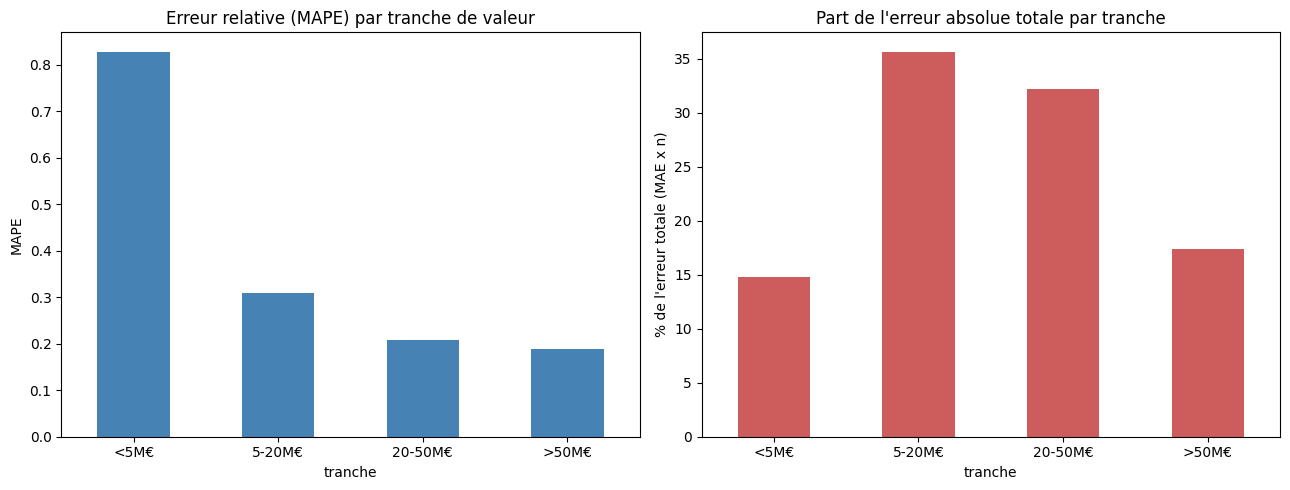

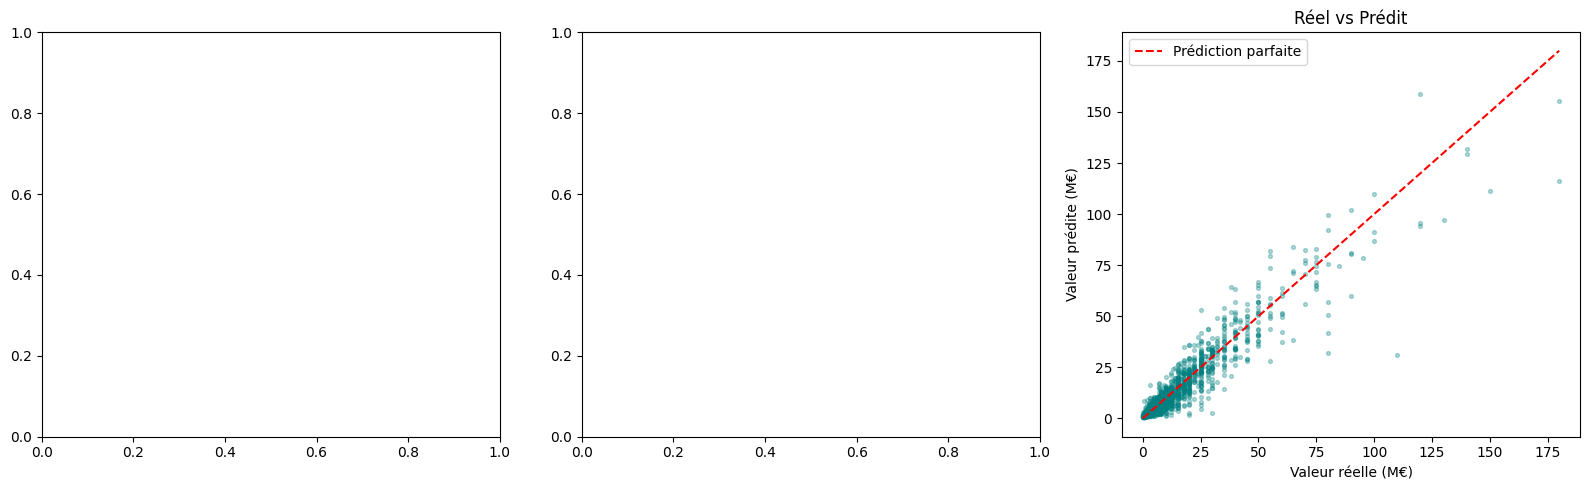

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

synthese_tranches["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Erreur relative (MAPE) par tranche de valeur")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=0)

synthese_tranches["% de l'erreur absolue totale"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Part de l'erreur absolue totale par tranche")
axes[1].set_ylabel("% de l'erreur totale (MAE x n)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Valeurs réelles vs prédites
sample = df_erreur.sample(min(2000, len(df_erreur)), random_state=RANDOM_STATE)
axes[2].scatter(sample["y_reel"] / 1e6, sample["y_pred"] / 1e6, alpha=0.3, s=8, color="teal")
lim = max(sample["y_reel"].max(), sample["y_pred"].max()) / 1e6
axes[2].plot([0, lim], [0, lim], "r--", lw=1.5, label="Prédiction parfaite")
axes[2].set_xlabel("Valeur réelle (M€)")
axes[2].set_ylabel("Valeur prédite (M€)")
axes[2].set_title("Réel vs Prédit")
axes[2].legend()

plt.tight_layout()
plt.show()

#### B3.4 — Feature importance (CatBoost)

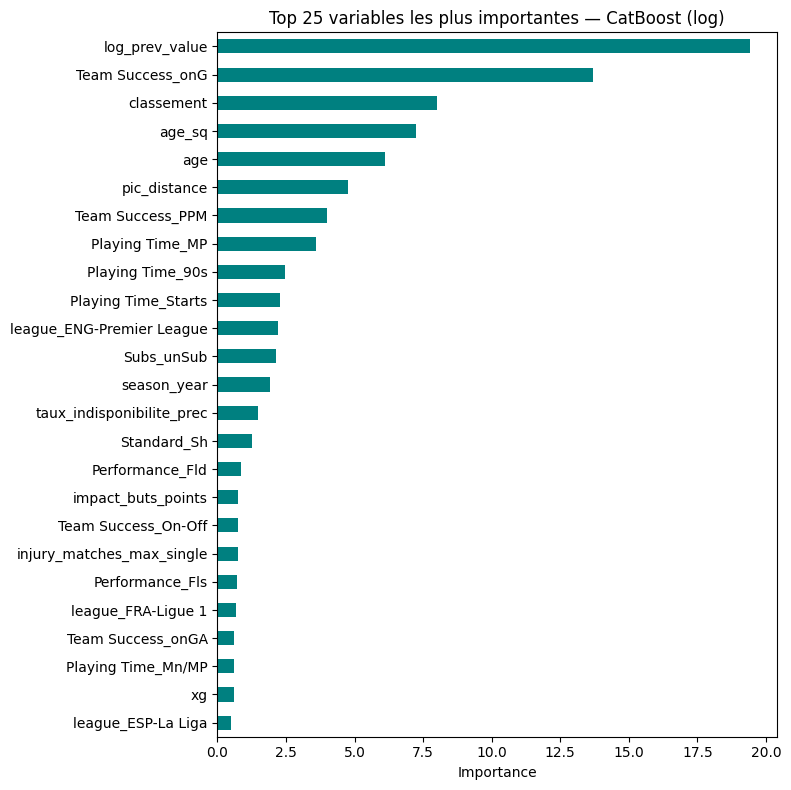

log_prev_value               19.427081
Team Success_onG             13.682868
classement                    8.019590
age_sq                        7.238953
age                           6.114823
pic_distance                  4.755920
Team Success_PPM              4.002661
Playing Time_MP               3.582968
Playing Time_90s              2.448508
Playing Time_Starts           2.277607
league_ENG-Premier League     2.206871
Subs_unSub                    2.127469
season_year                   1.898293
taux_indisponibilite_prec     1.472942
Standard_Sh                   1.265810
Performance_Fld               0.840777
impact_buts_points            0.746156
Team Success_On-Off           0.732434
injury_matches_max_single     0.730407
Performance_Fls               0.702132
league_FRA-Ligue 1            0.667269
Team Success_onGA             0.619968
Playing Time_Mn/MP            0.617720
xg                            0.611106
league_ESP-La Liga            0.489710
dtype: float64


In [15]:
importances = pd.Series(
    modeles_finaux["CatBoost (log)"].get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(25).sort_values().plot(kind="barh", color="teal")
plt.title("Top 25 variables les plus importantes — CatBoost (log)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances.head(25))

## Évaluation finale sur le TEST

> À lancer une seule fois, après avoir figé le choix du modèle sur la validation.

In [16]:
print("=== RÉSULTATS FINAUX (Test) ===")
resultats_test = {}
for label, preds in [
    ("Stacking OOF",  pred_test_stack),
    ("Moyenne simple",pred_test_moy),
    ("XGBoost seul",  np.expm1(preds_test_log["XGBoost (log)"])),
    ("LightGBM seul", np.expm1(preds_test_log["LightGBM (log)"])),
    ("CatBoost seul", np.expm1(preds_test_log["CatBoost (log)"])),
]:
    mae  = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    n, p = len(y_test), X_test.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    resultats_test[label] = {"MAPE": mape, "MAE": mae, "R2": r2, "R2 Ajusté": r2_adj}
    print(f"  {label:15s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f}")

df_test_final = pd.DataFrame(resultats_test).T.sort_values("MAPE")
print("\nClassement final (MAPE croissant) :")
print(df_test_final)

# Modèle retenu
meilleure_prediction_test = pred_test_stack

=== RÉSULTATS FINAUX (Test) ===
  Stacking OOF    | MAPE : 53.02% | MAE :    3,290,929 € | R² : 0.8905
  Moyenne simple  | MAPE : 39.88% | MAE :    3,287,597 € | R² : 0.8829
  XGBoost seul    | MAPE : 39.67% | MAE :    3,222,725 € | R² : 0.8838
  LightGBM seul   | MAPE : 40.57% | MAE :    3,374,719 € | R² : 0.8778
  CatBoost seul   | MAPE : 40.92% | MAE :    3,490,019 € | R² : 0.8690

Classement final (MAPE croissant) :
                    MAPE           MAE        R2  R2 Ajusté
XGBoost seul    0.396725  3.222725e+06  0.883819   0.873244
Moyenne simple  0.398755  3.287597e+06  0.882878   0.872217
LightGBM seul   0.405730  3.374719e+06  0.877764   0.866637
CatBoost seul   0.409229  3.490019e+06  0.869013   0.857091
Stacking OOF    0.530151  3.290929e+06  0.890506   0.880539


In [17]:
print("=== RÉSULTATS FINAUX (Année en cours) ===")
resultats_en_cours = {}
for label, preds in [
    ("Stacking OOF",  pred_en_cours_stack),
    ("Moyenne simple",pred_en_cours_moy),
    ("XGBoost seul",  np.expm1(preds_en_cours_log["XGBoost (log)"])),
    ("LightGBM seul", np.expm1(preds_en_cours_log["LightGBM (log)"])),
    ("CatBoost seul", np.expm1(preds_en_cours_log["CatBoost (log)"])),
]:
    mae  = mean_absolute_error(y_en_cours, preds)
    mape = mean_absolute_percentage_error(y_en_cours, preds)
    r2   = r2_score(y_en_cours, preds)
    n, p = len(y_en_cours), X_en_cours.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    resultats_en_cours[label] = {"MAPE": mape, "MAE": mae, "R2": r2, "R2 Ajusté": r2_adj}
    print(f"  {label:15s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f}")

df_en_cours_final = pd.DataFrame(resultats_en_cours).T.sort_values("MAPE")
print("\nClassement final (MAPE croissant) :")
print(df_en_cours_final)

# Modèle retenu
meilleure_prediction_en_cours = pred_en_cours_stack

=== RÉSULTATS FINAUX (Année en cours) ===
  Stacking OOF    | MAPE : 43.60% | MAE :    4,392,334 € | R² : 0.8247
  Moyenne simple  | MAPE : 39.83% | MAE :    4,692,286 € | R² : 0.8015
  XGBoost seul    | MAPE : 39.54% | MAE :    4,644,328 € | R² : 0.8046
  LightGBM seul   | MAPE : 40.38% | MAE :    4,678,831 € | R² : 0.8076
  CatBoost seul   | MAPE : 41.11% | MAE :    5,016,698 € | R² : 0.7741

Classement final (MAPE croissant) :
                    MAPE           MAE        R2  R2 Ajusté
XGBoost seul    0.395374  4.644328e+06  0.804591   0.781894
Moyenne simple  0.398276  4.692286e+06  0.801486   0.778429
LightGBM seul   0.403795  4.678831e+06  0.807584   0.785235
CatBoost seul   0.411082  5.016698e+06  0.774109   0.747872
Stacking OOF    0.435963  4.392334e+06  0.824670   0.804305


In [18]:
class StackingModel(BaseEstimator, RegressorMixin):

    def __init__(self, models, meta_model):
        self.models = models
        self.meta_model = meta_model

    def fit(self, X, y):
        # Pas besoin de réentraîner les modèles,
        # ils sont déjà entraînés dans ton notebook
        return self

    def predict(self, X):
        # Prédictions des modèles de niveau 1, repassées en euros (comme en cellule 17)
        X_meta = np.column_stack([
            np.expm1(model.predict(X)) for model in self.models
        ])

        # Le méta-modèle prédit directement en euros, pas besoin d'expm1 ensuite
        prediction_euros = self.meta_model.predict(X_meta)

        return prediction_euros



modele_stack = StackingModel(
    models=[
        modeles_finaux["XGBoost (log)"],
        modeles_finaux["LightGBM (log)"],
        modeles_finaux["CatBoost (log)"]
    ],
    meta_model=meta
)


print("--- PERMUTATION FEATURE IMPORTANCE ---")


result_perm = permutation_importance(
    modele_stack,
    X_val,
    y_val,
    scoring="r2",
    n_repeats=1,
    random_state=1308,
    n_jobs=-1
)


# Organisation des résultats
sorted_idx = result_perm.importances_mean.argsort()[::-1]


perm_importances = pd.DataFrame(
    {
        "Feature": X_val.columns[sorted_idx],
        "Importance_Mean": result_perm.importances_mean[sorted_idx],
        "Importance_Std": result_perm.importances_std[sorted_idx]
    }
)


print(perm_importances)

--- PERMUTATION FEATURE IMPORTANCE ---
                      Feature  Importance_Mean  Importance_Std
0              log_prev_value         0.378722             0.0
1            Team Success_onG         0.118326             0.0
2                         age         0.093353             0.0
3                  classement         0.054228             0.0
4                pic_distance         0.024034             0.0
..                        ...              ...             ...
141  sub_position_Centre-Back        -0.000334             0.0
142              Starts_Compl        -0.000673             0.0
143    injury_musculaire_nb_m        -0.000963             0.0
144                        xa        -0.001549             0.0
145                xg_buildup        -0.004317             0.0

[146 rows x 3 columns]


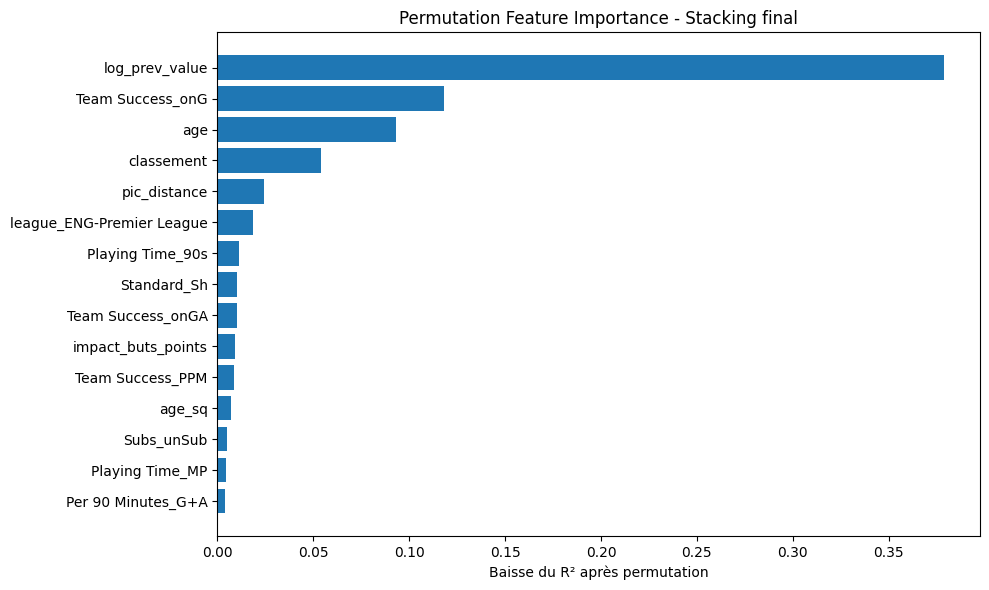

In [19]:
# Graphique
plt.figure(figsize=(10,6))

plt.barh(
    perm_importances["Feature"].head(15)[::-1],
    perm_importances["Importance_Mean"].head(15)[::-1],
    xerr=perm_importances["Importance_Std"].head(15)[::-1]
)

plt.xlabel("Baisse du R² après permutation")
plt.title("Permutation Feature Importance - Stacking final")
plt.tight_layout()
plt.show()

In [20]:
# print("Permutation Feature Importance par poste")

# # Liste des postes présents dans le jeu de validation
# postes = df_val["position"].dropna().unique().tolist()

# # Nombre minimum d'observations pour qu'un poste soit analysé (évite les postes anecdotiques)
# N_MIN_OBS = 30

# resultats_perm_par_poste = {}

# for poste in sorted(postes):
#     # Masque des lignes correspondant à ce poste (index aligné entre df_val, X_val, y_val)
#     mask = df_val["position"] == poste

#     if mask.sum() < N_MIN_OBS:
#         print(f"Poste '{poste}' ignoré ({mask.sum()} obs. < {N_MIN_OBS})")
#         continue

#     X_val_poste = X_val[mask.values]
#     y_val_poste = y_val[mask.values]

#     result_perm_poste = permutation_importance(
#         modele_stack,
#         X_val_poste,
#         y_val_poste,
#         scoring="neg_mean_absolute_percentage_error",
#         n_repeats=1,
#         random_state=1308,
#         n_jobs=-1
#     )

#     sorted_idx = result_perm_poste.importances_mean.argsort()[::-1]

#     perm_importances_poste = pd.DataFrame(
#         {
#             "Feature": X_val_poste.columns[sorted_idx],
#             "Importance_Mean": -result_perm_poste.importances_mean[sorted_idx],
#             "Importance_Std": result_perm_poste.importances_std[sorted_idx]
#         }
#     )

#     resultats_perm_par_poste[poste] = perm_importances_poste

#     print(f"\nPoste : {poste} (n={mask.sum()})")
#     print(perm_importances_poste.head(10))


# n_postes = len(resultats_perm_par_poste)
# fig, axes = plt.subplots(1, n_postes, figsize=(6 * n_postes, 6), sharex=False)

# if n_postes == 1:
#     axes = [axes]

# for ax, (poste, df_imp) in zip(axes, resultats_perm_par_poste.items()):
#     top = df_imp.head(10).iloc[::-1]
#     ax.barh(top["Feature"], top["Importance_Mean"], xerr=top["Importance_Std"], color="steelblue")
#     ax.set_title(f"Poste : {poste}")
#     ax.set_xlabel("Augmentation du MAPE après permutation")

# plt.tight_layout()
# plt.show()



Shap du stacking final


Background dataset has 2431 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2431 when initializing the masker.


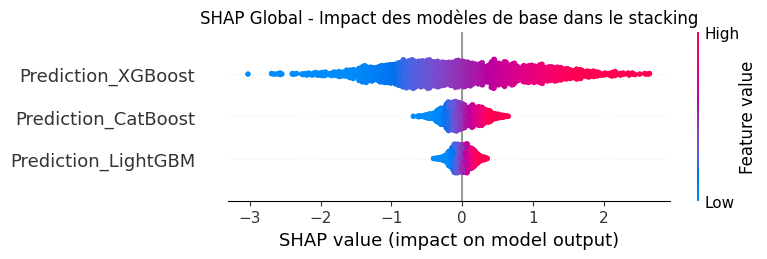

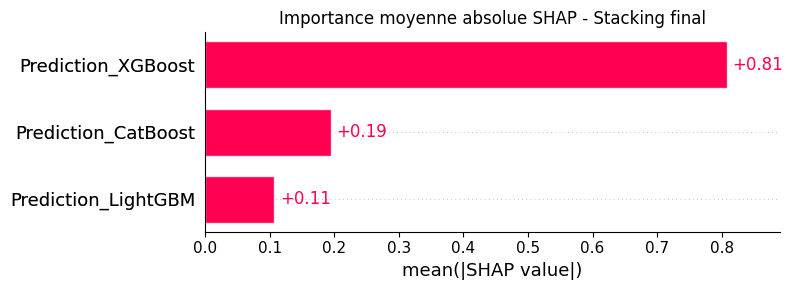


Explication locale de la première prédiction du jeu de validation


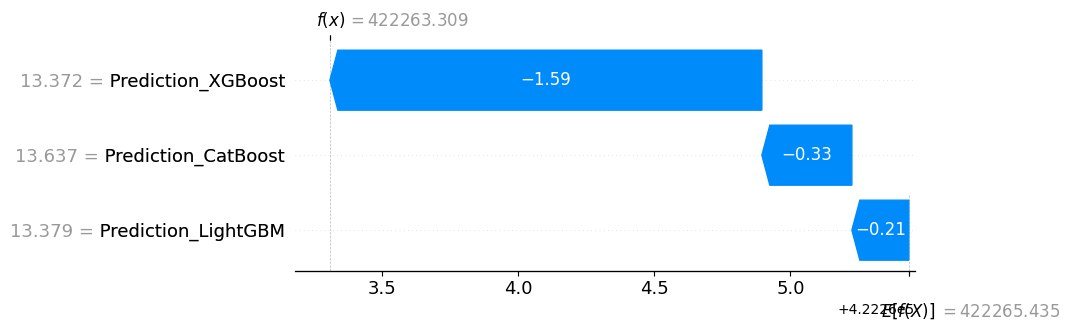

In [21]:
print("\nShap du stacking final")


# Le méta-modèle travaille sur les prédictions des modèles de base
X_meta_val = np.column_stack(
    [
        modeles_finaux["XGBoost (log)"].predict(X_val),
        modeles_finaux["LightGBM (log)"].predict(X_val),
        modeles_finaux["CatBoost (log)"].predict(X_val)
    ]
)


# Noms des variables du stacking
X_meta_val = pd.DataFrame(
    X_meta_val,
    columns=[
        "Prediction_XGBoost",
        "Prediction_LightGBM",
        "Prediction_CatBoost"
    ]
)


# Explainer adapté à LinearRegression
explainer = shap.LinearExplainer(
    meta,
    X_meta_val
)


shap_values = explainer(X_meta_val)



plt.figure(figsize=(10,6))

shap.plots.beeswarm(
    shap_values,
    max_display=10,
    show=False
)

plt.title(
    "SHAP Global - Impact des modèles de base dans le stacking"
)

plt.tight_layout()
plt.show()





plt.figure(figsize=(10,6))

shap.plots.bar(
    shap_values,
    max_display=10,
    show=False
)

plt.title(
    "Importance moyenne absolue SHAP - Stacking final"
)

plt.tight_layout()
plt.show()





print(
    "\nExplication locale de la première prédiction du jeu de validation"
)


shap.plots.waterfall(
    shap_values[0],
    max_display=10
)

In [22]:
def regrouper_shap(shap_values, groupes):
    """
    groupes : dict {"Nom affiché": ["col1", "col2", ...]}
    Additionne les valeurs SHAP des colonnes de chaque groupe en une seule variable.
    """
    feature_names = list(shap_values.feature_names)
    values = shap_values.values.copy()
    data = shap_values.data.copy()

    colonnes_groupees = [c for cols in groupes.values() for c in cols]
    colonnes_gardees = [c for c in feature_names if c not in colonnes_groupees]
    idx_gardees = [feature_names.index(c) for c in colonnes_gardees]

    nouvelles_values = values[:, idx_gardees]
    nouvelles_data   = data[:, idx_gardees]
    nouveaux_noms    = colonnes_gardees.copy()

    for nom_groupe, cols in groupes.items():
        idx_cols = [feature_names.index(c) for c in cols if c in feature_names]
        somme_values = values[:, idx_cols].sum(axis=1, keepdims=True)
        # On garde la valeur brute de la 1ère colonne du groupe pour l'affichage (ex: age brut)
        donnee_repr = data[:, idx_cols[0]:idx_cols[0]+1]

        nouvelles_values = np.hstack([nouvelles_values, somme_values])
        nouvelles_data   = np.hstack([nouvelles_data, donnee_repr])
        nouveaux_noms.append(nom_groupe)

    return shap.Explanation(
        values=nouvelles_values,
        base_values=shap_values.base_values,
        data=nouvelles_data,
        feature_names=nouveaux_noms
    )

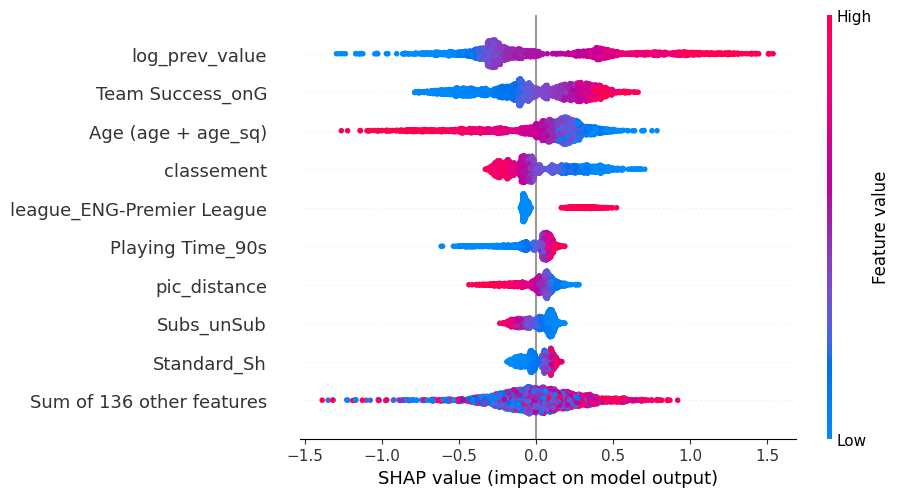

In [23]:
# Exemple sur XGBoost uniquement
explainer_xgb = shap.TreeExplainer(modeles_finaux["XGBoost (log)"])

shap_values_xgb = explainer_xgb(X_val)

groupes = {"Age (age + age_sq)": ["age", "age_sq"]}

shap_values_xgb_grouped = regrouper_shap(shap_values_xgb, groupes)

shap.plots.beeswarm(shap_values_xgb_grouped)

refaire le même avec barres et sous-cas (exemple donné par Thibault)

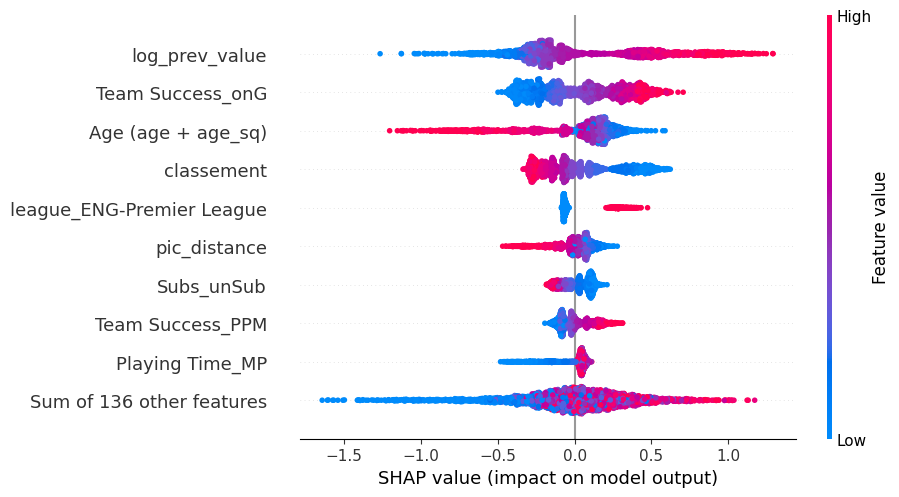

In [24]:
# Exemple sur CatBoost uniquement
explainer_cb = shap.TreeExplainer(modeles_finaux["CatBoost (log)"])
shap_values_cb = explainer_cb(X_val)

shap_values_cb_grouped = regrouper_shap(shap_values_cb, groupes)

shap.plots.beeswarm(shap_values_cb_grouped)

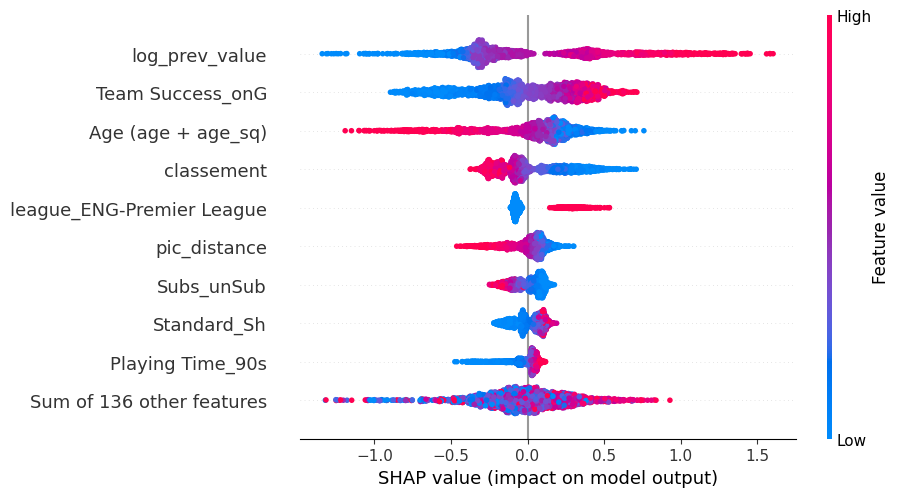

In [25]:
# Exemple sur LightGBM uniquement
explainer_lgb = shap.TreeExplainer(modeles_finaux["LightGBM (log)"])
shap_values_lgb = explainer_lgb(X_val)

shap_values_lgb_grouped = regrouper_shap(shap_values_lgb, groupes)

shap.plots.beeswarm(shap_values_lgb_grouped)

In [73]:
# ------------------------------------------------------------------
# À mettre UNE FOIS au-dessus de tes fonctions (dict_variables actuel + palette_pro actuelle)
# ------------------------------------------------------------------
DICT_VARIABLES = {
        # Famille : Identité, âge et physique
        "player": ("Nom du joueur", "Identité et physique"),
        "team": ("Club du joueur", "Identité et physique"),
        "nation": ("Nationalité", "Identité et physique"),
        "Age (age + age_sq)": ("Âge du joueur", "Identité et physique"),
        "pic_distance": ("Distance de l'âge du pic de valeur", "Identité et physique"),
        "pic_age": ("Âge du pic de valeur (0/1)", "Identité et physique"),
        "height_in_cm": ("Taille (en cm)", "Identité et physique"),
        "position": ("Poste général", "Identité et physique"),
        "foot_both": ("Ambidextre (0/1)", "Identité et physique"),
        "foot_left": ("Gaucher (0/1)", "Identité et physique"),
        "foot_right": ("Droitier (0/1)", "Identité et physique"),
        # Famille : Postes et sub-positions
        "pos_DF": ("Défenseur (0/1)", "Postes"),
        "pos_FW": ("Attaquant (0/1)", "Postes"),
        "pos_GK": ("Gardien de but (0/1)", "Postes"),
        "pos_MF": ("Milieu de terrain (0/1)", "Postes"),
        "sub_position_Attacking Midfield": (
            "Milieu offensif (0/1)",
            "Postes",
        ),
        "sub_position_Central Midfield": (
            "Milieu central (0/1)",
            "Postes",
        ),
        "sub_position_Centre-Back": (
            "Défenseur central (0/1)",
            "Postes",
        ),
        "sub_position_Centre-Forward": (
            "Avant-centre (0/1)",
            "Postes",
        ),
        "sub_position_Defensive Midfield": (
            "Milieu défensif (0/1)",
            "Postes",
        ),
        "sub_position_Goalkeeper": (
            "Gardien (Sous-poste 0/1)",
            "Postes",
        ),
        "sub_position_Left Midfield": (
            "Milieu gauche (0/1)",
            "Postes",
        ),
        "sub_position_Left Winger": (
            "Ailier gauche (0/1)",
            "Postes",
        ),
        "sub_position_Left-Back": (
            "Latéral gauche (0/1)",
            "Postes",
        ),
        "sub_position_Right Midfield": (
            "Milieu droit (0/1)",
            "Postes",
        ),
        "sub_position_Right Winger": (
            "Ailier droit (0/1)",
            "Postes",
        ),
        "sub_position_Right-Back": (
            "Latéral droit (0/1)",
            "Postes",
        ),
        "sub_position_Second Striker": (
            "Neuf et demi / Second attaquant (0/1)",
            "Postes",
        ),
        "est_polyvalent": (
            "Joueur polyvalent (0/1)",
            "Postes",
        ),
        # Famille : Championnats et contexte international
        "league_ENG-Premier League": (
            "Évolue en Premier League (0/1)",
            "Ligues et contexte international",
        ),
        "league_ESP-La Liga": (
            "Évolue en La Liga (0/1)",
            "Ligues et contexte international",
        ),
        "league_FRA-Ligue 1": (
            "Évolue en Ligue 1 (0/1)",
            "Ligues et contexte international",
        ),
        "league_GER-Bundesliga": (
            "Évolue en Bundesliga (0/1)",
            "Ligues et contexte international",
        ),
        "league_ITA-Serie A": (
            "Évolue en Serie A (0/1)",
            "Ligues et contexte international",
        ),
        "classement_FIFA_1": (
            "Sélection nationale Rang FIFA : 1",
            "Ligues et contexte international",
        ),
        "classement_FIFA_2": (
            "Sélection nationale Rang FIFA : 2",
            "Ligues et contexte international",
        ),
        "classement_FIFA_3": (
            "Sélection nationale Rang FIFA : 3",
            "Ligues et contexte international",
        ),
        "classement_FIFA_4": (
            "Sélection nationale Rang FIFA : 4",
            "Ligues et contexte international",
        ),
        "classement_FIFA_5": (
            "Sélection nationale Rang FIFA : 5",
            "Ligues et contexte international",
        ),
        "classement_FIFA_6": (
            "Sélection nationale Rang FIFA : 6",
            "Ligues et contexte international",
        ),
        "classement_FIFA_7": (
            "Sélection nationale Rang FIFA : 7",
            "Ligues et contexte international",
        ),
        "classement_FIFA_8": (
            "Sélection nationale Rang FIFA : 8",
            "Ligues et contexte international",
        ),
        "classement_FIFA_9": (
            "Sélection nationale Rang FIFA : 9",
            "Ligues et contexte international",
        ),
        "classement_FIFA_10": (
            "Sélection nationale Rang FIFA : 10",
            "Ligues et contexte international",
        ),
        "score_hype_nation": (
            "Score de hype de la sélection nationale",
            "Ligues et contexte international",
        ),
        # Famille : Temps de jeu, contrat et chronologie
        "season_year": ("Année de la saison", "Temps de jeu & Contrat"),
        "delta_minutes_jouees": (
            "Différence de minutes jouées par rapport à la saison précédente",
            "Temps de jeu et contrat",
        ),
        "contrat_jours_restants": (
            "Jours de contrat restants",
            "Temps de jeu et contrat",
        ),
        "Playing Time_MP": ("Matchs disputés", "Temps de jeu et contrat"),
        "Playing Time_Starts": (
            "Titularisations",
            "Temps de jeu et contrat",
        ),
        "Playing Time_90s": (
            "Nombre de 90 minutes complétées",
            "Temps de jeu et contrat",
        ),
        "Playing Time_Mn/MP": (
            "Minutes jouées par match disputé",
            "Temps de jeu et contrat",
        ),
        "Starts_Mn/Start": (
            "Minutes par titularisation",
            "Temps de jeu et contrat",
        ),
        "Starts_Compl": (
            "Matchs commencés et terminés en entier",
            "Temps de jeu et contrat",
        ),
        "Subs_Subs": (
            "Entrées en cours de match (Remplaçant)",
            "Temps de jeu et contrat",
        ),
        "Subs_Mn/Sub": ("Minutes par entrée en jeu", "Temps de jeu et contrat"),
        "Subs_unSub": (
            "Matchs passés sur le banc sans entrer",
            "Temps de jeu et contrat",
        ),
        "taux_matchs_termines": (
            "Taux de matchs terminés",
            "Temps de jeu et contrat",
        ),
        # Famille : Performance Offensive (Volume et efficacité)
        "Performance_Gls": ("Buts marqués", "Performance offensive"),
        "Performance_Ast": ("Passes décisives", "Performance offensive"),
        "Performance_G-PK": ("Buts hors pénaltys", "Performance offensive"),
        "Performance_PK": ("Pénaltys marqués", "Performance offensive"),
        "Performance_PKatt": ("Pénaltys tentés", "Performance offensive"),
        "Standard_Sh": ("Tirs totaux effectués", "Performance offensive"),
        "Standard_SoT": ("Tirs cadrés", "Performance offensive"),
        "Standard_SoT%": (
            "Pourcentage de tirs cadrés",
            "Performance offensive",
        ),
        "Standard_Sh/90": (
            "Tirs effectués par 90 min",
            "Performance offensive",
        ),
        "Standard_SoT/90": ("Tirs cadrés par 90 min", "Performance offensive"),
        "Standard_G/Sh": ("Buts par tir tenté", "Performance offensive"),
        "Standard_G/SoT": ("Buts par tir cadré", "Performance offensive"),
        "Performance_Off": ("Hors-jeux signalés", "Performance offensive"),
        "Performance_Crs": ("Centres vers la surface", "Performance offensive"),
        "Performance_PKwon": ("Pénaltys obtenus", "Performance offensive"),
        "Per 90 Minutes_Gls": ("Buts par 90 min", "Performance offensive"),
        "Per 90 Minutes_Ast": (
            "Passes décisives par 90 min",
            "Performance offensive",
        ),
        "Per 90 Minutes_G+A": (
            "Buts + Assists par 90 min",
            "Performance offensive",
        ),
        "Performance_Fld": ("Fautes subies", "Performance offensive"),
        "indice_danger_tirs": (
            "Indice de danger des tirs (xG par tir)", "Performance offensive"
        ),
        "efficacite_devant_but": (
            "Efficacité devant le but", "Performance offensive"
        ),
        "contribution_offensive_equipe": (
            "Contribution offensive à l'équipe (Buts + Assists / Total équipe)", "Performance offensive"
        ),
        "rentabilite_buts_minutes": (
            "Rentabilité des buts par minute jouée", "Performance offensive"
        ),
        "impact_buts_points": (
            "Impact des buts sur les points gagnés par l'équipe", "Performance offensive"
        ),
        "ratio_buts_hors_penalty": (
            "Ratio de buts hors pénaltys", "Performance offensive"
        ),
        "ratio_buts_penalty": (
            "Ratio de buts sur pénaltys", "Performance offensive"
        ),
        # Famille : Statistiques avancées (xG, xA, Création)
        "xg": ("Expected Goals (xG)", "Statistiques avancées"),
        "delta_xg": (
            "Différence de xG par rapport à la saison précédente", "Statistiques avancées"
        ),
        "xa": ("Expected Assists (xa)", "Statistiques avancées"),
        "xg_chain": (
            "Chaîne Expected Goals (xG Chain)",
            "Statistiques avancées",
        ),
        "xg_buildup": (
            "Construction Expected Goals",
            "Statistiques avancées",
        ),
        # Famille : Discipline et performance défensive
        "Performance_CrdY": ("Cartons jaunes reçus", "Discipline et défense"),
        "Performance_CrdR": ("Cartons rouges reçus", "Discipline et défense"),
        "ratio_agressivite": (
            "Ratio agressivité", "Discipline et défense"
        ),
        "Performance_2CrdY": (
            "Expulsions suite à 2 jaunes",
            "Discipline et défense",
        ),
        "Performance_Fls": ("Fautes commises", "Discipline et défense"),
        "Performance_Int": ("Interceptions de passes", "Discipline et défense"),
        "Performance_TklW": ("Tacles réussis", "Discipline et défense"),
        "Performance_PKcon": ("Pénaltys concédés", "Discipline et défense"),
        "Performance_OG": (
            "Buts contre son camp (OG)",
            "Discipline et défense",
        ),
        "indiscipline_par_90": (
            "Indiscipline par 90 min",
            "Discipline et défense"
        ),
        # Famille : Collectif et succès équipe
        "classement": ("Classement de l'équipe", "Succès équipe et collectif"),
        "Team Success_PPM": (
            "Points par match gagnés par l'équipe",
            "Succès équipe et collectif",
        ),
        "Team Success_onG": (
            "Buts marqués par l'équipe (si présent)",
            "Succès équipe et collectif",
        ),
        "Team Success_onGA": (
            "Buts encaissés par l'équipe (si présent)",
            "Succès équipe et collectif",
        ),
        "Team Success_On-Off": (
            "Impact On-Off de la présence du joueur",
            "Succès équipe et collectif",
        ),
        # Famille : Spécifique Gardien de but
        "Performance_GA": ("Buts encaissés", "Spécifique gardien"),
        "Performance_GA90": (
            "Buts encaissés par 90 min",
            "Spécifique gardien",
        ),
        "Performance_Saves": ("Arrêts effectués", "Spécifique gardien"),
        "Performance_Save%": ("Pourcentage d'arrêts", "Spécifique gardien"),
        "Performance_W": (
            "Victoires de l'équipe (si présent)",
            "Spécifique gardien",
        ),
        "Performance_D": (
            "Matchs nuls de l'équipe (si présent)",
            "Spécifique gardien",
        ),
        "Performance_L": (
            "Défaites de l'équipe (si présent)",
            "Spécifique gardien",
        ),
        "Performance_CS": (
            "Clean Sheets (Matchs sans but)",
            "Spécifique gardien",
        ),
        "Performance_CS%": (
            "Pourcentage de Clean Sheets",
            "Spécifique gardien",
        ),
        "Penalty Kicks_PKA": ("Pénaltys encaissés", "Spécifique gardien"),
        "Penalty Kicks_PKsv": ("Pénaltys arrêtés", "Spécifique gardien"),
        "Penalty Kicks_PKm": (
            "Pénaltys ratés par l'adversaire",
            "Spécifique gardien",
        ),
        "Penalty Kicks_Save%": (
            "Pourcentage de pénaltys arrêtés",
            "Spécifique gardien",
        ),
        "taux_arretXtaille_gardien": (
            "Taux d'arrêts par rapport à la taille du gardien", "Spécifique gardien"
        ),
        # Famille : Historique médical (Blessures)
        "injury_nb_total": ("Nombre total de blessures", "Historique médical"),
        "injury_days_total": (
            "Total des jours d'absence",
            "Historique médical",
        ),
        "injury_matches_max_single": (
            "Max de matchs manqués sur une blessure",
            "Historique médical",
        ),
        "injury_musculaire": (
            "Blessure musculaire (Présence 0/1)",
            "Historique médical",
        ),
        "injury_musculaire_nb_d": (
            "Jours d'absence - Muscle",
            "Historique médical",
        ),
        "injury_musculaire_nb_m": (
            "Matchs manqués - Muscle",
            "Historique médical",
        ),
        "injury_genou": (
            "Blessure au genou (Présence 0/1)",
            "Historique médical",
        ),
        "injury_genou_nb_d": ("Jours d'absence - Genou", "Historique médical"),
        "injury_genou_nb_m": ("Matchs manqués - Genou", "Historique médical"),
        "injury_cheville_pied": (
            "Blessure cheville/pied (Présence 0/1)",
            "Historique médical",
        ),
        "injury_cheville_pied_nb_d": (
            "Jours d'absence - Cheville/Pied",
            "Historique médical",
        ),
        "injury_cheville_pied_nb_m": (
            "Matchs manqués - Cheville/Pied",
            "Historique médical",
        ),
        "injury_mollet_tibia": (
            "Blessure mollet/tibia (Présence 0/1)",
            "Historique médical",
        ),
        "injury_mollet_tibia_nb_d": (
            "Jours d'absence - Mollet/Tibia",
            "Historique médical",
        ),
        "injury_mollet_tibia_nb_m": (
            "Matchs manqués - Mollet/Tibia",
            "Historique médical",
        ),
        "injury_dos_bassin": (
            "Blessure dos/bassin (Présence 0/1)",
            "Historique médical",
        ),
        "injury_dos_bassin_nb_d": (
            "Jours d'absence - Dos/Bassin",
            "Historique médical",
        ),
        "injury_dos_bassin_nb_m": (
            "Matchs manqués - Dos/Bassin",
            "Historique médical",
        ),
        "injury_trauma_severe": (
            "Traumatisme sévère/Opération (Présence 0/1)",
            "Historique médical",
        ),
        "injury_trauma_severe_nb_d": (
            "Jours d'absence - Traumatisme Sévère",
            "Historique médical",
        ),
        "injury_trauma_severe_nb_m": (
            "Matchs manqués - Traumatisme Sévère",
            "Historique médical",
        ),
        "injury_medical_repos": (
            "Maladie / Repos obligatoire (Présence 0/1)",
            "Historique médical",
        ),
        "injury_medical_repos_nb_d": (
            "Jours d'absence - Maladie/Repos",
            "Historique médical",
        ),
        "injury_medical_repos_nb_m": (
            "Matchs manqués - Maladie/Repos",
            "Historique médical",
        ),
        "injury_minor_unknown": (
            "Blessure mineure/inconnue (Présence 0/1)",
            "Historique médical",
        ),
        "injury_minor_unknown_nb_d": (
            "Jours d'absence - Blessure mineure",
            "Historique médical",
        ),
        "injury_minor_unknown_nb_m": (
            "Matchs manqués - Blessure mineure",
            "Historique médical",
        ),
        "taux_indisponibilite": (
            "Taux d'indisponibilité (Jours d'absence / 365)",
            "Historique médical",
        ),
        "fragilite_chronique": (
            "Fragilité chronique (0/1)",
            "Historique médical",
        ),
    }

DICT_VARIABLES["log_prev_value"] = (
       "Valeur marchande (log) - Saison précédente",
       "Temps de jeu et contrat",
   )

PALETTE_PRO = {
    "Identité et physique": "#2B3A4A",             # Bleu nuit / Ardoise
    "Postes": "#0066FF",                            # Bleu électrique vif
    "Ligues et contexte international": "#00A896",   # Teal / Vert d'eau foncé
    "Temps de jeu et contrat": "#00B4D8",            # Cyan / Bleu ciel vif
    "Performance offensive": "#FF5A5F",              # Coral / Rouge vif
    "Statistiques avancées": "#8E44AD",             # Violet profond
    "Discipline et défense": "#E67E22",             # Orange cuivré
    "Succès équipe et collectif": "#2ECC71",        # Vert émeraude
    "Spécifique gardien": "#F1C40F",                 # Jaune ambre
    "Historique médical": "#E056FD",               # Rose néon / Magenta
    "Non Classifié": "#95A5A6",                     # Gris neutre
}

def renommer_features_shap(shap_values, dict_variables=DICT_VARIABLES, palette=PALETTE_PRO):
    """Remplace les feature_names techniques par les noms métier,
    et retourne {nom_affiché: couleur_famille} pour colorer les labels ensuite."""
    noms_originaux = list(shap_values.feature_names)

    noms_affiches = []
    couleur_par_label = {}
    for nom in noms_originaux:
        description, famille = dict_variables.get(nom, (nom, "Non Classifié"))
        noms_affiches.append(description)
        couleur_par_label[description] = palette.get(famille, "#2e3440")

    shap_values.feature_names = noms_affiches
    return couleur_par_label


def colorer_labels_waterfall(fig_ou_ax, couleur_par_label, couleur_defaut="#2e3440"):
    """Colore les labels du waterfall SHAP selon la famille de la variable.
    Ne modifie QUE la couleur (jamais le fontweight), car SHAP superpose deux
    couches de texte parfaitement alignées (valeur grise + nom noir) et changer
    la graisse de la police désaligne les deux couches (effet de texte dédoublé)."""
    fig = fig_ou_ax.figure if hasattr(fig_ou_ax, "figure") else fig_ou_ax
    ax = fig.axes[0]  # le premier axe contient les 2 couches de texte réellement visibles
    for label in ax.get_yticklabels():
        texte = label.get_text().strip()
        if texte in couleur_par_label:
            label.set_color(couleur_par_label[texte])

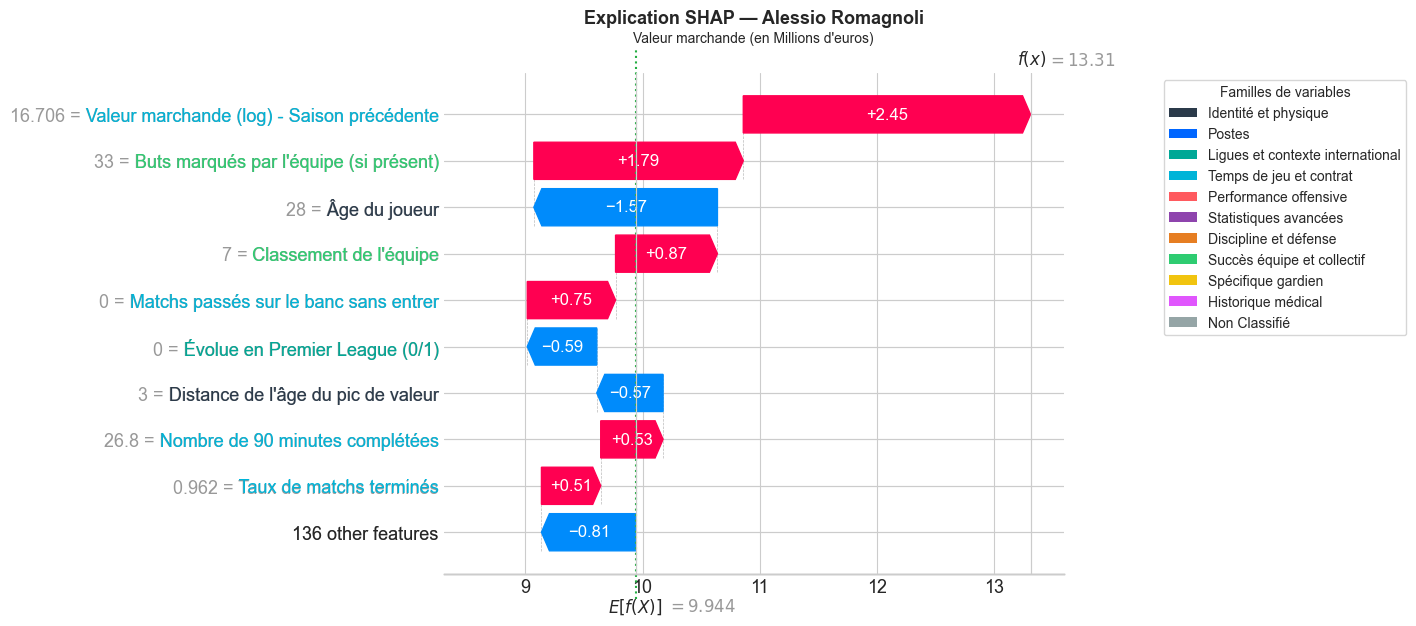

In [74]:
# Définition du modèle et des données
model_xgb = modeles_finaux["XGBoost (log)"]
indice_joueur = 90

nom_joueur = df_val[colonne_joueur].iloc[indice_joueur]

def predict_m_euro(X):
    return np.exp(model_xgb.predict(X)) / 1_000_000

background_data = shap.sample(X_val, 100)
explainer_m_euro = shap.Explainer(predict_m_euro, background_data)
shap_values_m_euro = explainer_m_euro(X_val.iloc[[indice_joueur]])

shap_values_m_euro_grouped = regrouper_shap(shap_values_m_euro, groupes)

shap_joueur = shap_values_m_euro_grouped[0]
couleur_par_label = renommer_features_shap(shap_joueur)

# Affichage du waterfall SHAP
plt.figure(figsize=(14, 6))
shap.plots.waterfall(shap_joueur, show=False)

fig = plt.gcf()
ax_reel = fig.axes[0]

colorer_labels_waterfall(fig, couleur_par_label)

# --- Remplacer la ligne E[f(X)] par des pointillés ---
e_fx = float(shap_joueur.base_values if np.isscalar(shap_joueur.base_values) else shap_joueur.base_values[0])

# Tolérance relative à l'échelle de l'axe (plus fiable qu'une valeur absolue fixe)
x_min, x_max = ax_reel.get_xlim()
tolerance = 0.01 * abs(x_max - x_min)  # 1% de la largeur du graphe

# On supprime TOUTES les lignes proches de E[f(X)], sur TOUS les axes de la figure
# (SHAP peut dessiner plusieurs segments à cette position : petite marque + trait)
for ax in fig.axes:
    for line in list(ax.lines):
        xdata = line.get_xdata()
        if len(xdata) >= 2 and np.isclose(xdata[0], xdata[-1]) and abs(xdata[0] - e_fx) < tolerance:
            line.remove()

# On trace notre unique ligne pointillée, sans clipping pour être sûr qu'elle couvre tout
ax_reel.axvline(
    x=e_fx, color="#23ad41", linestyle=":", linewidth=1.5,
    zorder=10, clip_on=False, ymin=-0.05, ymax=1.05,
)


# Légende des familles
familles_utilisees = {c: f for f, c in PALETTE_PRO.items() if c in couleur_par_label.values()}
legend_elements = [Patch(facecolor=c, label=f) for c, f in familles_utilisees.items()]
if legend_elements:
    ax_reel.legend(
        handles=legend_elements,
        title="Familles de variables",
        bbox_to_anchor=(1.15, 1),
        loc="upper left",
        frameon=True
    )

plt.title(f"Explication SHAP — {nom_joueur}", fontsize=13, fontweight="bold")
plt.xlabel("Valeur marchande (en Millions d'euros)")
plt.tight_layout()
plt.show()

In [60]:
fig = plt.gcf()
e_fx_calcule = float(shap_joueur.base_values if np.isscalar(shap_joueur.base_values) else shap_joueur.base_values[0])
print("e_fx calculé :", e_fx_calcule)

print("\nLignes verticales trouvées dans la figure :")
for i, ax in enumerate(fig.axes):
    for line in ax.lines:
        xdata = line.get_xdata()
        if len(xdata) >= 2 and np.isclose(xdata[0], xdata[-1]):
            print(f"  axe {i} -> x = {xdata[0]:.6f}  (écart avec e_fx: {abs(xdata[0]-e_fx_calcule):.6f})")

e_fx calculé : 9.94440594047308

Lignes verticales trouvées dans la figure :


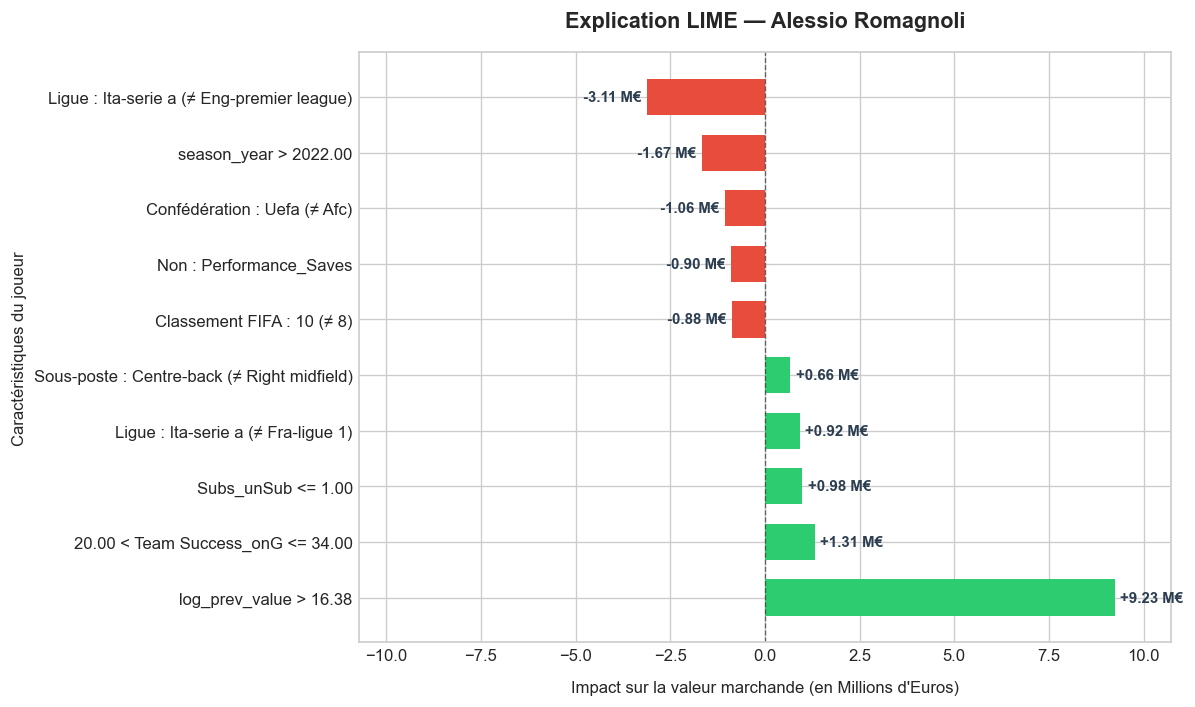

In [86]:
indice_joueur = 90

nom_joueur = df_val[colonne_joueur].iloc[indice_joueur]

model = modeles_finaux["XGBoost (log)"]

# Imputation des NaN pour LIME
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns)

# Fonction de prédiction en Millions d'Euros
def predict_m_euro(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_train.columns)
    log_preds = model.predict(X)
    return np.exp(log_preds) / 1_000_000

# Création de l'explicateur LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_imputed),
    feature_names=list(X_train.columns),
    class_names=['Valeur_M_Euro'],
    mode='regression',
    random_state=1308,
    feature_selection='highest_weights'
)

# Extraction des données du joueur choisi
joueur_data = X_test_imputed.iloc[indice_joueur].values

# Calcul de l'explication LIME
exp = explainer.explain_instance(
    data_row=joueur_data,
    predict_fn=predict_m_euro,
    num_features=10,
)



# Extraction des données
list_exp = exp.as_list()
df_lime = pd.DataFrame(list_exp, columns=['Feature_Condition', 'Impact'])
df_lime = df_lime.sort_values(by='Impact', ascending=False)

# Nettoyage des étiquettes
def clean_feature_label(condition):
    if "<= 0.00" in condition:
        feat = condition.replace(" <= 0.00", "")
        return f"Non : {feat}"
    elif "> 0.00" in condition:
        feat = condition.replace(" > 0.00", "")
        return f"Oui : {feat}"
    return condition

df_lime['Pretty_Label'] = df_lime['Feature_Condition'].apply(clean_feature_label)
df_lime['Color'] = df_lime['Impact'].apply(lambda x: '#2ecc71' if x > 0 else '#e74c3c')

# Dictionnaire des familles de variables encodées en "one-hot" (dummies)
# clé = préfixe technique de la colonne, valeur = nom affiché de la famille
FAMILLES_ONE_HOT = {
    "confederation_": "Confédération",
    "league_": "Ligue",
    "pos_": "Poste",
    "sub_position_": "Sous-poste",
    "foot_": "Pied fort",
    "classement_FIFA" : "Classement FIFA",
    # ajoute ici tout autre préfixe de dummy présent dans ton dataset
}


def trouver_famille_one_hot(nom_colonne, familles=FAMILLES_ONE_HOT):
    """Retourne (prefixe, nom_famille) si la colonne appartient à une famille one-hot connue, sinon None."""
    for prefixe, nom_famille in familles.items():
        if nom_colonne.startswith(prefixe):
            return prefixe, nom_famille
    return None


def valeur_reelle_categorie(joueur_row, prefixe):
    """Cherche, parmi les colonnes de ce préfixe, celle qui vaut 1 pour ce joueur,
    et retourne son nom nettoyé (ex: 'confederation_europe' -> 'Europe')."""
    colonnes_famille = [c for c in joueur_row.index if c.startswith(prefixe)]
    for col in colonnes_famille:
        if joueur_row[col] == 1:
            return col[len(prefixe):].replace("_", " ").strip().capitalize()
    return "Inconnu"


def clean_feature_label(condition, joueur_row):
    """Nettoie le libellé LIME. Pour les variables one-hot, affiche la VRAIE
    catégorie du joueur plutôt qu'un simple Oui/Non peu explicite."""

    if "<= 0.00" in condition:
        feat = condition.replace(" <= 0.00", "").strip()
        est_positif = False
    elif "> 0.00" in condition:
        feat = condition.replace(" > 0.00", "").strip()
        est_positif = True
    else:
        return condition  # variable numérique continue : on laisse tel quel

    famille = trouver_famille_one_hot(feat)

    if famille is not None:
        prefixe, nom_famille = famille
        valeur_reelle = valeur_reelle_categorie(joueur_row, prefixe)
        categorie_testee = feat[len(prefixe):].replace("_", " ").strip().capitalize()

        if est_positif:
            # La condition testée est vraie -> c'est bien sa catégorie
            return f"{nom_famille} : {valeur_reelle}"
        else:
            # La condition testée est fausse -> on affiche sa VRAIE catégorie
            return f"{nom_famille} : {valeur_reelle} (≠ {categorie_testee})"

    # Cas générique : variable binaire simple qui n'est pas dans FAMILLES_ONE_HOT
    return f"Non : {feat}" if not est_positif else f"Oui : {feat}"


df_lime['Pretty_Label'] = df_lime['Feature_Condition'].apply(
    lambda cond: clean_feature_label(cond, X_test_imputed.iloc[indice_joueur])
)

# Création de la figure
plt.figure(figsize=(10, 6), dpi=120)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

bars = plt.barh(
    y=df_lime['Pretty_Label'], 
    width=df_lime['Impact'], 
    color=df_lime['Color'],
    edgecolor='none',
    height=0.65
)

plt.axvline(x=0, color='#333333', linestyle='--', linewidth=0.8, alpha=0.7)

# Textes au bout des barres
for bar in bars:
    width = bar.get_width()
    x_pos = width + (0.15 if width > 0 else -0.15)
    ha = 'left' if width > 0 else 'right'
    
    plt.text(
        x_pos, 
        bar.get_y() + bar.get_height()/2, 
        f"{width:+.2f} M€", 
        va='center', 
        ha=ha, 
        fontsize=9, 
        fontweight='bold',
        color='#2c3e50'
    )

# Titre et axes
plt.title(f"Explication LIME — {nom_joueur}", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("Impact sur la valeur marchande (en Millions d'Euros)", fontsize=10, labelpad=10)
plt.ylabel("Caractéristiques du joueur", fontsize=10)

x_max = max(abs(df_lime['Impact'].min()), abs(df_lime['Impact'].max())) + 1.5
plt.xlim(-x_max, x_max)

plt.tight_layout()
plt.show()

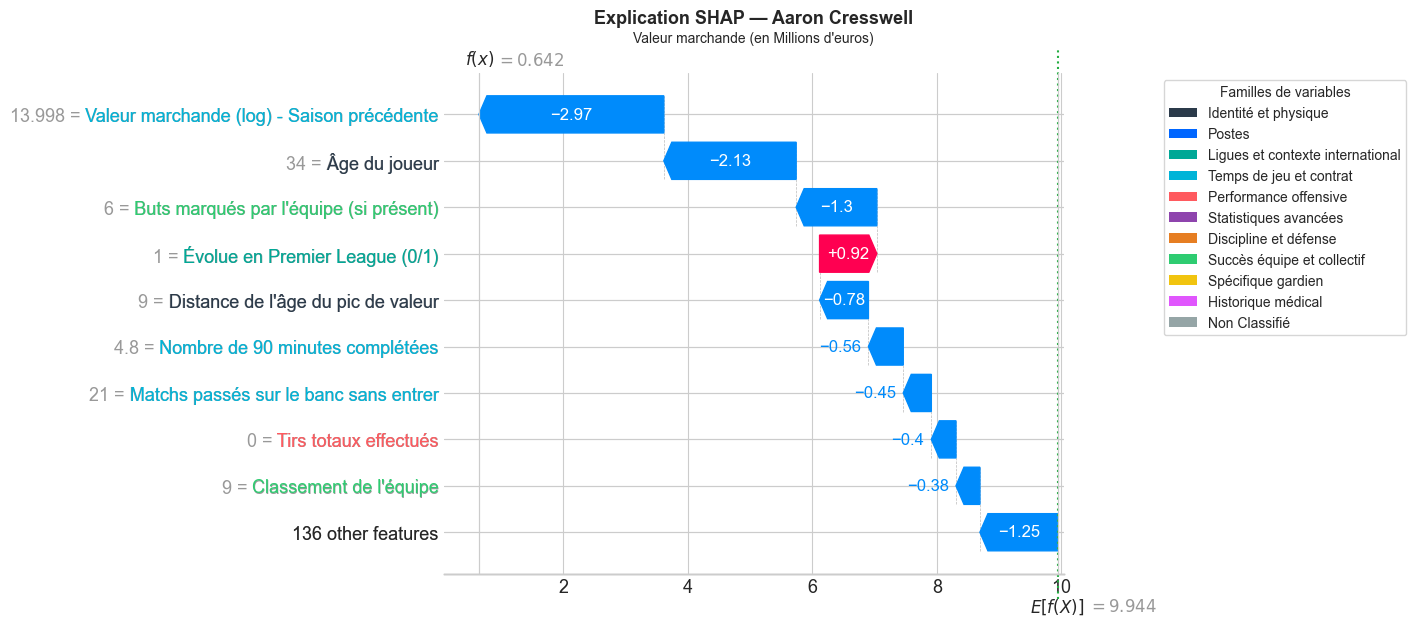

In [75]:
# Définition du modèle et des données
model_xgb = modeles_finaux["XGBoost (log)"]
indice_joueur = 0

nom_joueur = df_val[colonne_joueur].iloc[indice_joueur]

def predict_m_euro(X):
    return np.exp(model_xgb.predict(X)) / 1_000_000

background_data = shap.sample(X_val, 100)
explainer_m_euro = shap.Explainer(predict_m_euro, background_data)
shap_values_m_euro = explainer_m_euro(X_val.iloc[[indice_joueur]])

shap_values_m_euro_grouped = regrouper_shap(shap_values_m_euro, groupes)

shap_joueur = shap_values_m_euro_grouped[0]
couleur_par_label = renommer_features_shap(shap_joueur)

# Affichage du waterfall SHAP
plt.figure(figsize=(14, 6))
shap.plots.waterfall(shap_joueur, show=False)

fig = plt.gcf()
ax_reel = fig.axes[0]

colorer_labels_waterfall(fig, couleur_par_label)

# --- Remplacer la ligne E[f(X)] par des pointillés ---
e_fx = float(shap_joueur.base_values if np.isscalar(shap_joueur.base_values) else shap_joueur.base_values[0])

# Tolérance relative à l'échelle de l'axe (plus fiable qu'une valeur absolue fixe)
x_min, x_max = ax_reel.get_xlim()
tolerance = 0.01 * abs(x_max - x_min)  # 1% de la largeur du graphe

# On supprime TOUTES les lignes proches de E[f(X)], sur TOUS les axes de la figure
# (SHAP peut dessiner plusieurs segments à cette position : petite marque + trait)
for ax in fig.axes:
    for line in list(ax.lines):
        xdata = line.get_xdata()
        if len(xdata) >= 2 and np.isclose(xdata[0], xdata[-1]) and abs(xdata[0] - e_fx) < tolerance:
            line.remove()

# On trace notre unique ligne pointillée, sans clipping pour être sûr qu'elle couvre tout
ax_reel.axvline(
    x=e_fx, color="#23ad41", linestyle=":", linewidth=1.5,
    zorder=10, clip_on=False, ymin=-0.05, ymax=1.05,
)


# Légende des familles
familles_utilisees = {c: f for f, c in PALETTE_PRO.items() if c in couleur_par_label.values()}
legend_elements = [Patch(facecolor=c, label=f) for c, f in familles_utilisees.items()]
if legend_elements:
    ax_reel.legend(
        handles=legend_elements,
        title="Familles de variables",
        bbox_to_anchor=(1.15, 1),
        loc="upper left",
        frameon=True
    )

plt.title(f"Explication SHAP — {nom_joueur}", fontsize=13, fontweight="bold")
plt.xlabel("Valeur marchande (en Millions d'euros)")
plt.tight_layout()
plt.show()

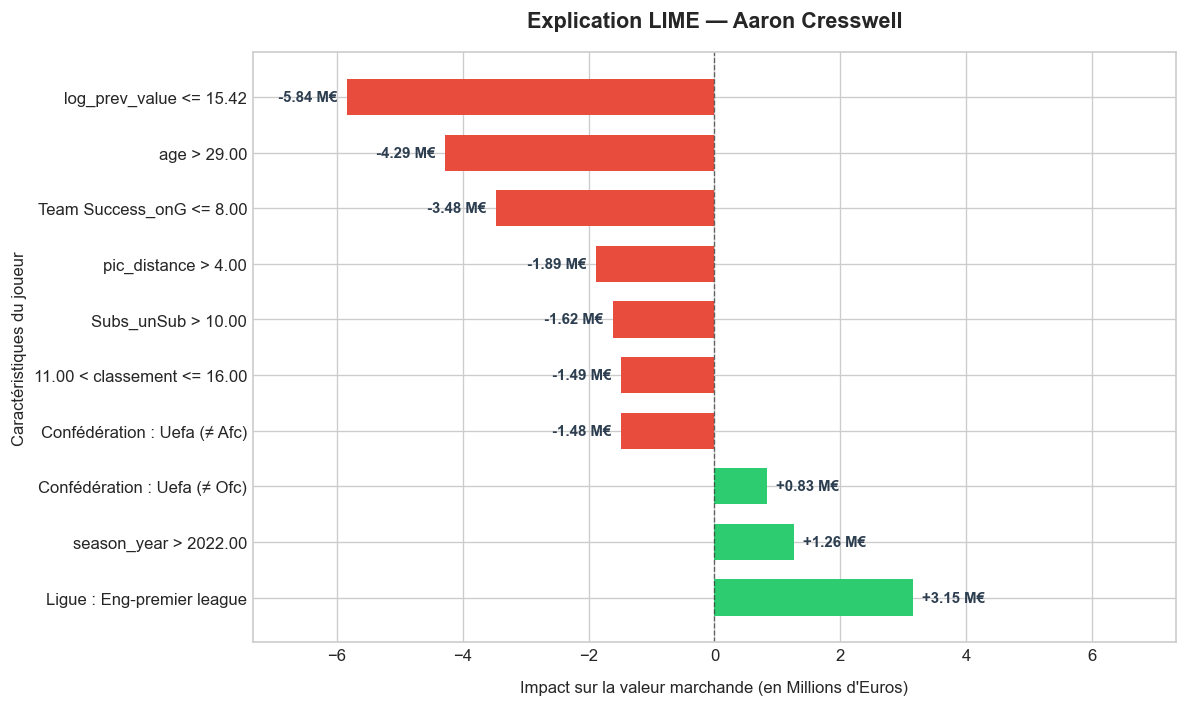

In [88]:
indice_joueur = 0

nom_joueur = df_test[colonne_joueur].iloc[indice_joueur]

model = modeles_finaux["XGBoost (log)"]

# Imputation des NaN pour LIME
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Fonction de prédiction en Millions d'Euros
def predict_m_euro(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_train.columns)
    log_preds = model.predict(X)
    return np.exp(log_preds) / 1_000_000

# Création de l'explicateur LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_imputed),
    feature_names=list(X_train.columns),
    class_names=['Valeur_M_Euro'],
    mode='regression',
    random_state=1308,
    feature_selection='highest_weights'
)

# Extraction des données du joueur choisi
joueur_data = X_test_imputed.iloc[indice_joueur].values

# Calcul de l'explication LIME
exp = explainer.explain_instance(
    data_row=joueur_data,
    predict_fn=predict_m_euro,
    num_features=10
)



# Extraction des données
list_exp = exp.as_list()
df_lime = pd.DataFrame(list_exp, columns=['Feature_Condition', 'Impact'])
df_lime = df_lime.sort_values(by='Impact', ascending=False)

# Nettoyage des étiquettes
def clean_feature_label(condition):
    if "<= 0.00" in condition:
        feat = condition.replace(" <= 0.00", "")
        return f"Non : {feat}"
    elif "> 0.00" in condition:
        feat = condition.replace(" > 0.00", "")
        return f"Oui : {feat}"
    return condition

df_lime['Pretty_Label'] = df_lime['Feature_Condition'].apply(clean_feature_label)
df_lime['Color'] = df_lime['Impact'].apply(lambda x: '#2ecc71' if x > 0 else '#e74c3c')

# Dictionnaire des familles de variables encodées en "one-hot" (dummies)
# clé = préfixe technique de la colonne, valeur = nom affiché de la famille
FAMILLES_ONE_HOT = {
    "confederation_": "Confédération",
    "league_": "Ligue",
    "pos_": "Poste",
    "sub_position_": "Sous-poste",
    "foot_": "Pied fort",
    "classement_FIFA" : "Classement FIFA",
}


def trouver_famille_one_hot(nom_colonne, familles=FAMILLES_ONE_HOT):
    """Retourne (prefixe, nom_famille) si la colonne appartient à une famille one-hot connue, sinon None."""
    for prefixe, nom_famille in familles.items():
        if nom_colonne.startswith(prefixe):
            return prefixe, nom_famille
    return None


def valeur_reelle_categorie(joueur_row, prefixe):
    """Cherche, parmi les colonnes de ce préfixe, celle qui vaut 1 pour ce joueur,
    et retourne son nom nettoyé (ex: 'confederation_europe' -> 'Europe')."""
    colonnes_famille = [c for c in joueur_row.index if c.startswith(prefixe)]
    for col in colonnes_famille:
        if joueur_row[col] == 1:
            return col[len(prefixe):].replace("_", " ").strip().capitalize()
    return "Inconnu"


def clean_feature_label(condition, joueur_row):
    """Nettoie le libellé LIME. Pour les variables one-hot, affiche la VRAIE
    catégorie du joueur plutôt qu'un simple Oui/Non peu explicite."""

    if "<= 0.00" in condition:
        feat = condition.replace(" <= 0.00", "").strip()
        est_positif = False
    elif "> 0.00" in condition:
        feat = condition.replace(" > 0.00", "").strip()
        est_positif = True
    else:
        return condition  # variable numérique continue : on laisse tel quel

    famille = trouver_famille_one_hot(feat)

    if famille is not None:
        prefixe, nom_famille = famille
        valeur_reelle = valeur_reelle_categorie(joueur_row, prefixe)
        categorie_testee = feat[len(prefixe):].replace("_", " ").strip().capitalize()

        if est_positif:
            # La condition testée est vraie -> c'est bien sa catégorie
            return f"{nom_famille} : {valeur_reelle}"
        else:
            # La condition testée est fausse -> on affiche sa VRAIE catégorie
            return f"{nom_famille} : {valeur_reelle} (≠ {categorie_testee})"

    # Cas générique : variable binaire simple qui n'est pas dans FAMILLES_ONE_HOT
    return f"Non : {feat}" if not est_positif else f"Oui : {feat}"


df_lime['Pretty_Label'] = df_lime['Feature_Condition'].apply(
    lambda cond: clean_feature_label(cond, X_test_imputed.iloc[indice_joueur])
)

# Création de la figure
plt.figure(figsize=(10, 6), dpi=120)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

bars = plt.barh(
    y=df_lime['Pretty_Label'], 
    width=df_lime['Impact'], 
    color=df_lime['Color'],
    edgecolor='none',
    height=0.65
)

plt.axvline(x=0, color='#333333', linestyle='--', linewidth=0.8, alpha=0.7)

# Textes au bout des barres
for bar in bars:
    width = bar.get_width()
    x_pos = width + (0.15 if width > 0 else -0.15)
    ha = 'left' if width > 0 else 'right'
    
    plt.text(
        x_pos, 
        bar.get_y() + bar.get_height()/2, 
        f"{width:+.2f} M€", 
        va='center', 
        ha=ha, 
        fontsize=9, 
        fontweight='bold',
        color='#2c3e50'
    )

# Titre et axes
plt.title(f"Explication LIME — {nom_joueur}", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("Impact sur la valeur marchande (en Millions d'Euros)", fontsize=10, labelpad=10)
plt.ylabel("Caractéristiques du joueur", fontsize=10)

x_max = max(abs(df_lime['Impact'].min()), abs(df_lime['Impact'].max())) + 1.5
plt.xlim(-x_max, x_max)

plt.tight_layout()
plt.show()